<a href="https://colab.research.google.com/github/untungbensugih/tugas_1_machinelearning/blob/main/Tugas%201%20Machine%20Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Untung Sugiono (052713741)

--- Struktur dan Tipe Data ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             4 non-null      object 
 1   Nama           3 non-null      object 
 2   Jenis_Kelamin  3 non-null      object 
 3   Prodi          3 non-null      object 
 4   Status         3 non-null      object 
 5   Nilai_Akhir    1 non-null      object 
 6   Tanggal_Ujian  3 non-null      object 
 7   Umur           2 non-null      float64
dtypes: float64(1), object(7)
memory usage: 388.0+ bytes
None

--- Jumlah Nilai Hilang ---
ID               0
Nama             1
Jenis_Kelamin    1
Prodi            1
Status           1
Nilai_Akhir      3
Tanggal_Ujian    1
Umur             2
dtype: int64

--- Statistik Deskriptif ---
            Umur
count   2.000000
mean   23.500000
std     6.363961
min    19.000000
25%    21.250000
50%    23.500000
75%    25.750000
max    

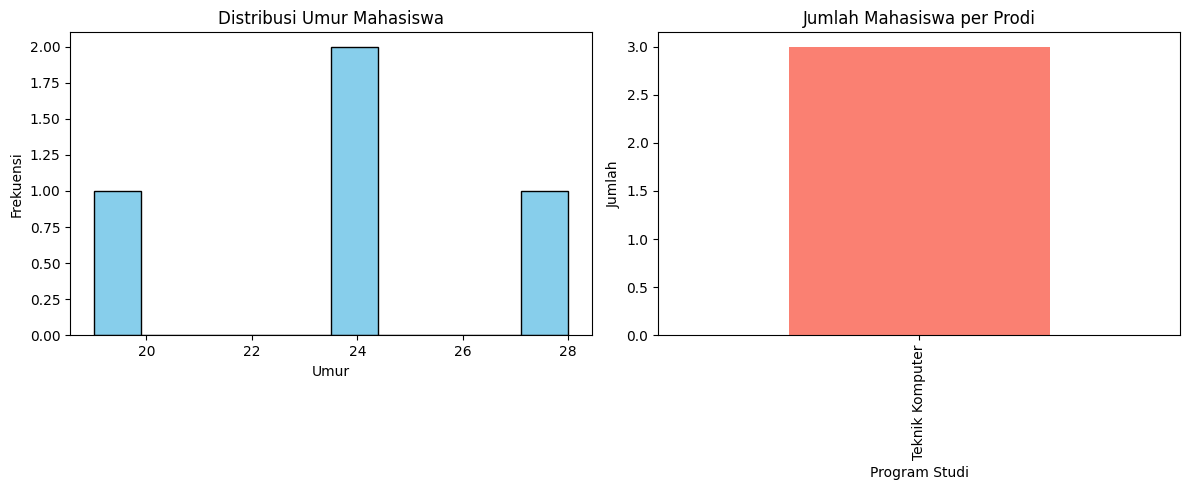

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from io import StringIO

# --- Tahap 1: Load Dataset ---

csv_data = """ID,Nama,Jenis_Kelamin,Prodi,Status,Nilai_Akhir,Tanggal_Ujian,Umur
MH001,Iwan,Laki-laki,Teknik Komputer,Aktif,,13-04-2020,
MH002,Eka,Perempuan,Teknik Komputer,Lulus,E,2020/12/11,28.0
... (isi data lainnya sesuai file csv Anda) ...
MH099,Hana,Perempuan,Teknik Komputer,DO,,2021/10/18,19.0"""

# df = pd.read_csv('DOC-20260506-WA0032..csv')

# Membaca data ke DataFrame
df = pd.read_csv(StringIO(csv_data))

# --- Tahap 2: Eksplorasi Awal (EDA) ---
print("--- Struktur dan Tipe Data ---")
print(df.info())
print("\n--- Jumlah Nilai Hilang ---")
print(df.isnull().sum())
print("\n--- Statistik Deskriptif ---")
print(df.describe())

# --- Tahap 3: Menangani Missing Values ---
# Imputasi Umur dengan Mean (Rata-rata)
df['Umur'] = df['Umur'].fillna(df['Umur'].mean())

# Imputasi Nilai_Akhir dengan Modus (karena kategorikal)
df['Nilai_Akhir'] = df['Nilai_Akhir'].fillna(df['Nilai_Akhir'].mode()[0])

# --- Tahap 4: Normalisasi Format Tanggal ---
df['Tanggal_Ujian'] = pd.to_datetime(df['Tanggal_Ujian'], dayfirst=True, errors='coerce')

# --- Tahap 5: Encoding Label ---
le = LabelEncoder()
cols_to_encode = ['Nama', 'Jenis_Kelamin', 'Prodi', 'Status', 'Nilai_Akhir']

for col in cols_to_encode:
    df[col] = le.fit_transform(df[col].astype(str))

# --- Tahap 6: Split Data ---
# Memisahkan fitur (X) dan target (y). Contoh target: Status
X = df.drop(['ID', 'Status', 'Tanggal_Ujian'], axis=1)
y = df['Status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\nUkuran Data Latih: {X_train.shape}")
print(f"Ukuran Data Uji: {X_test.shape}")

# --- Tahap 7: Visualisasi ---
plt.figure(figsize=(12, 5))

# Histogram Umur
plt.subplot(1, 2, 1)
plt.hist(df['Umur'], bins=10, color='skyblue', edgecolor='black')
plt.title('Distribusi Umur Mahasiswa')
plt.xlabel('Umur')
plt.ylabel('Frekuensi')

# Grafik Batang Prodi (Kembali ke data asli untuk label yang jelas)
df_original = pd.read_csv(StringIO(csv_data)) # Reload untuk visualisasi label asli
plt.subplot(1, 2, 2)
df_original['Prodi'].value_counts().plot(kind='bar', color='salmon')
plt.title('Jumlah Mahasiswa per Prodi')
plt.xlabel('Program Studi')
plt.ylabel('Jumlah')

plt.tight_layout()
plt.show()